# 水印 Mask 检测：可视化

四栏：**水印图 / 原图 / 水印 mask / overlay**。

推理走同目录的 `infer.py`（门控融合 + 尺度匹配，无后处理）。
数据目录在第一个代码块顶部指定，里面放 `source/` 和 `candidate/` 两个子目录即可。


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# 中文字体，否则标题里的中文会渲染成方块
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import torch
from PIL import Image

# ---- 只改这一处：数据目录 --------------------------------------------------
# 目录里放 source/ 和 candidate/ 两个子目录，按文件名主干配对：
#     source/xxx.jpg  <->  candidate/xxx.png
DATA_DIR = Path('/home/lyq/projects/图像去水印/0-数据/mask-pairs')
# ---------------------------------------------------------------------------

THRESHOLD = 0.35   # 概率阈值，偏召回（mask 外会回退到原图，漏检比过检严重）
MAX_IMAGES = 0     # 0 = 全部

# 定位本模型目录（代码不依赖目录叫什么名字）
MODEL_DIR = Path.cwd().resolve()
if not (MODEL_DIR / 'infer.py').is_file():
    for candidate in ('3-2/mask-model', 'mask-model', 'handoff', 'mask-model/handoff', '.'):
        path = Path(candidate)
        if (path / 'infer.py').is_file():
            MODEL_DIR = path.resolve()
            break
assert (MODEL_DIR / 'infer.py').is_file(), f'找不到 infer.py（当前目录 {Path.cwd()}）'
sys.path.insert(0, str(MODEL_DIR))
# 强制重新加载 infer / models：Jupyter 内核会缓存已导入的模块，
# 改了 infer.py 之后不重启内核会继续用旧版本。
for _name in [n for n in list(sys.modules)
              if n in ('infer', 'models') or n.startswith('models.')]:
    sys.modules.pop(_name, None)
from infer import load_model, predict, TILE, OVERLAP

model, DEVICE, INFO = load_model(MODEL_DIR / 'weights/watermark_mask.pt')
print('model     :', MODEL_DIR)
print('data      :', DATA_DIR)
print('architecture=%s epoch=%s best_iou=%s device=%s' % (
    INFO['architecture'], INFO['epoch'], INFO['best_iou'], DEVICE))


model     : /home/lyq/projects/图像去水印/mask-model/handoff
data      : /home/lyq/projects/图像去水印/0-数据/mask-pairs
architecture=difference_gate_scale epoch=6 best_iou=0.7642301017750459 device=cuda


In [2]:
# 按文件名主干配对 source/ 与 candidate/
assert DATA_DIR.is_dir(), f'数据目录不存在: {DATA_DIR}'
source_dir, candidate_dir = DATA_DIR / 'source', DATA_DIR / 'candidate'
assert source_dir.is_dir() and candidate_dir.is_dir(), \
    f'{DATA_DIR} 下需要有 source/ 和 candidate/ 两个子目录'

pairs = []
for source_path in sorted(p for p in source_dir.iterdir() if p.is_file()):
    candidate_path = candidate_dir / f'{source_path.stem}.png'
    if candidate_path.is_file():
        pairs.append((source_path, candidate_path))
if MAX_IMAGES:
    pairs = pairs[:MAX_IMAGES]
print(f'{len(pairs)} 对图像')

results = []
for index, (source_path, candidate_path) in enumerate(pairs, 1):
    with Image.open(source_path) as handle:
        source = handle.convert('RGB')
    with Image.open(candidate_path) as handle:
        candidate = handle.convert('RGB')
    out = predict(model, source, candidate, DEVICE, tile=TILE, overlap=OVERLAP)
    probability = out['probability']
    mask = probability >= THRESHOLD

    overlay = np.asarray(source, dtype=np.float32) / 255.0
    overlay[mask] = 0.3 * overlay[mask] + 0.7 * np.array([0.0, 0.85, 1.0])

    results.append({
        'id': source_path.stem,
        'source': np.asarray(source),
        'candidate': np.asarray(candidate),
        'mask': mask,
        'overlay': (overlay.clip(0, 1) * 255).astype(np.uint8),
        'mask_fraction': float(mask.mean()),
        'scale_mismatch': out['scale_mismatch'],
        'matched_scale': out['matched_scale'],
    })
    print(f"[{index}/{len(pairs)}] {source_path.stem}: mask={mask.mean()*100:.2f}% "
          f"mismatch={out['scale_mismatch']:.2f}x matched={out['matched_scale']}")
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


35 对图像


[1/35] 日常图片水印_1: mask=10.81% mismatch=0.73x matched=False


[2/35] 日常图片水印_2: mask=7.89% mismatch=1.11x matched=False


[3/35] 日常图片水印_3: mask=1.99% mismatch=0.36x matched=False


[4/35] 日常图片水印_7: mask=7.41% mismatch=3.38x matched=True
[5/35] 日常图片水印_8: mask=1.89% mismatch=0.36x matched=False


...

[31/35] 试卷水印_IMG_7335.HEIC: mask=3.53% mismatch=3.41x matched=True


[32/35] 试卷水印_IMG_7336.HEIC: mask=2.50% mismatch=3.41x matched=True


[33/35] 试卷水印_IMG_7337.HEIC: mask=3.06% mismatch=3.41x matched=True


[34/35] 试卷水印_IMG_7338.HEIC: mask=5.32% mismatch=3.41x matched=True


[35/35] 试卷水印_IMG_7339.HEIC: mask=8.19% mismatch=3.44x matched=True


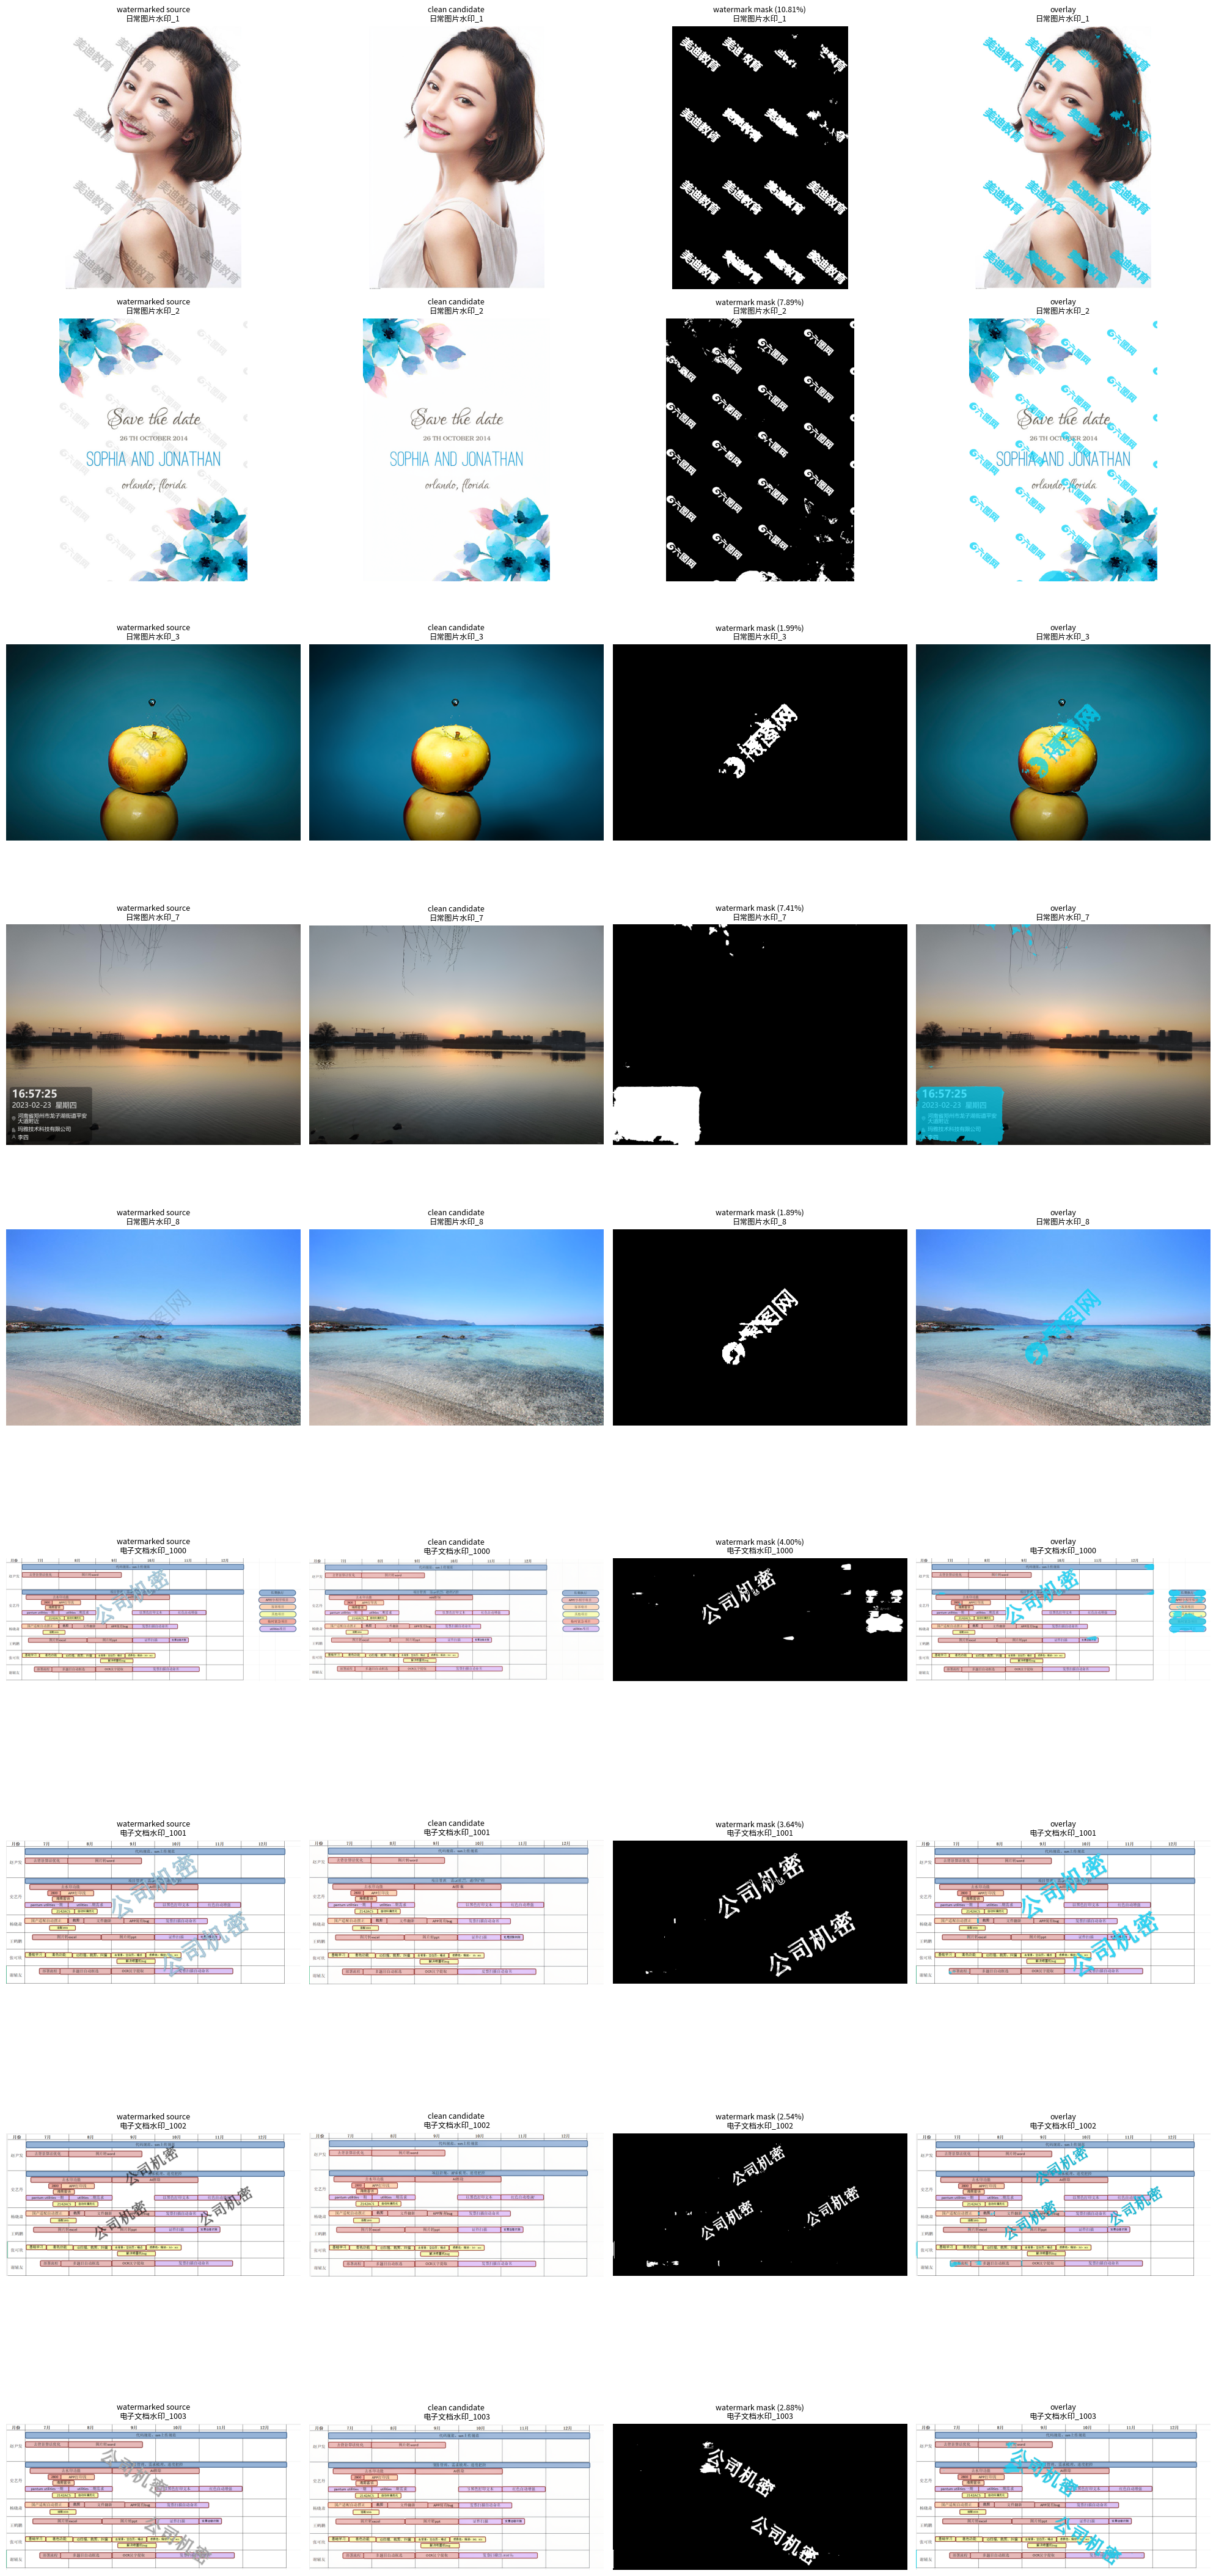

,id,mask_fraction,scale_mismatch,matched_scale
0,日常图片水印_1,0.108102,0.734375,False
1,日常图片水印_2,0.078895,1.111111,False
2,日常图片水印_3,0.019911,0.360577,False
3,日常图片水印_7,0.074094,3.378378,True
4,日常图片水印_8,0.018919,0.360577,False
5,电子文档水印_1000,0.040004,1.042929,False
6,电子文档水印_1001,0.036413,0.957201,False
7,电子文档水印_1002,0.025402,0.963315,False
8,电子文档水印_1003,0.028817,0.962225,False
9,电子文档水印_1004,0.048628,0.760913,False


In [3]:
def show_results(limit=9):
    """四栏：水印图 / 原图 / 水印 mask / overlay。"""
    selected = results[:limit] if limit else results
    if not selected:
        print('没有可显示的结果')
        return
    fig, axes = plt.subplots(len(selected), 4, figsize=(20, 4.8 * len(selected)))
    axes = np.atleast_2d(axes)
    for row, result in enumerate(selected):
        panels = (
            (result['source'], 'watermarked source'),
            (result['candidate'], 'clean candidate'),
            (result['mask'], f"watermark mask ({result['mask_fraction'] * 100:.2f}%)"),
            (result['overlay'], 'overlay'),
        )
        for col, (image, title) in enumerate(panels):
            axes[row, col].imshow(image, cmap='gray' if col == 2 else None,
                                  vmin=0 if col == 2 else None, vmax=1 if col == 2 else None)
            axes[row, col].set_title(f"{title}\n{result['id']}", fontsize=9)
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

show_results(limit=9)
display(pd.DataFrame([{k: v for k, v in r.items()
                       if k in ('id', 'mask_fraction', 'scale_mismatch', 'matched_scale')}
                      for r in results]))


## 已知限制

1. **极低局部对比度的水印会漏检。** 实测一个淡印章的内部差异比其紧邻外圈还小
   （局部对比度 0.63x），差分判别原理上定位不到；同一张图的斜向水印文字是 7.0x，
   能正常检出。放宽阈值无效。
2. **候选图没有改动的地方检不出来。** 若某水印区的 `|source - candidate|` 接近 0，
   没有基于差异的方法能判断那里有水印。
3. **大面积彩色图形会过检**（实测某泳道图 27.6%），属训练数据缺口。
